In [1]:
import numpy as np
import bacco
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
def pars(i, mstar):

    arr = np.vstack( ( mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * rho_rec[i],\
                        np.ones(len(mstar)) * sf_ts[i],\
                        np.ones(len(mstar)) * ef_kin[i],\
                        np.ones(len(mstar)) * ef_high[i],\
                        np.ones(len(mstar)) * f_re[i])).T

    return arr

In [4]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))

rho_rec_or = np.log10(rho_rec_or)
ef_kin_or = np.log10(ef_kin_or)
        
wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

In [5]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = {}

for i in range(len(name_list)):
    if i<30:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_{:d}/hydro_output/".format(i)
    else:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)


2026-03-20 22:12:55,857 bacco.sims : Initialising simulation Default
2026-03-20 22:12:55,858 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264
2026-03-20 22:12:55,860 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264


2026-03-20 22:12:56,211 bacco.sims : ...done in 0.00799 s
2026-03-20 22:12:56,212 bacco.sims : Initialising simulation Default
2026-03-20 22:12:56,212 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-03-20 22:12:56,214 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-03-20 22:12:56,556 bacco.sims : ...done in 0.00522 s
2026-03-20 22:12:56,557 bacco.sims : Initialising simulation Default
2026-03-20 22:12:56,557 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2026-03-20 22:12:56,559 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2026-03-20 22:12:56,563 bacco.sims : ...done in 0.00525 s
2026-03-20 22:12:56,564 bacco.sims : Initialising simulation Default
2026-03-20 22:12:56,565 bacco.sims : try /cosmos_storage/simulations/TNG_Fa

In [6]:
# Load the Halo Selection
with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

# Perform the cross-match with MTNG halos
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264, name=name_list[i])

# Load MTNG and get the fraction of halos to do the upweighting
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

zoom_split = {}
zoom_sel = {}
for i in range(len(name_list)):
    zoom_split[name_list[i]] = utils.split_halos(zoom[name_list[i]])

    zoom_sel[name_list[i]] = {}

    zoom_sel[name_list[i]]['sel'] = xmatch[name_list[i]]['ind'][:,np.newaxis,np.newaxis]
    zoom_sel[name_list[i]]['h_frac'] = h_frac[np.newaxis, :]

2026-03-20 22:13:00,967 bacco.sims : Initialising simulation Default
2026-03-20 22:13:00,968 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-03-20 22:13:00,969 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264


2026-03-20 22:13:00,999 bacco.sims : ...done in 0.00623 s
2026-03-20 22:13:01,003 bacco.sims : Reading 98233510 items for Group_M_Mean200
/tmp/ipykernel_89411/87356854.py:19: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])


In [13]:
sSFR_mstar = {}

for i in range(30,31):
    sSFR_mstar[name_list[i]] = zoom_split[name_list[i]].sSFR_mstar(sel_mask=zoom_sel[name_list[i]], nbins=20)

/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:269: RuntimeWarning: divide by zero encountered in divide
  sSFR_array = self.sim.sub['SFR'] / ( 1e10 * self.sim.sub['MassType'][:,4] / self.sim.header['HubbleParam'] )
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:269: RuntimeWarning: invalid value encountered in divide
  sSFR_array = self.sim.sub['SFR'] / ( 1e10 * self.sim.sub['MassType'][:,4] / self.sim.header['HubbleParam'] )
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:292: RuntimeWarning: invalid value encountered in divide
  sSFR_mean = sSFR_mean / counts
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:293: RuntimeWarning: invalid value encountered in divide
  mstar_mean = mstar_mean / counts


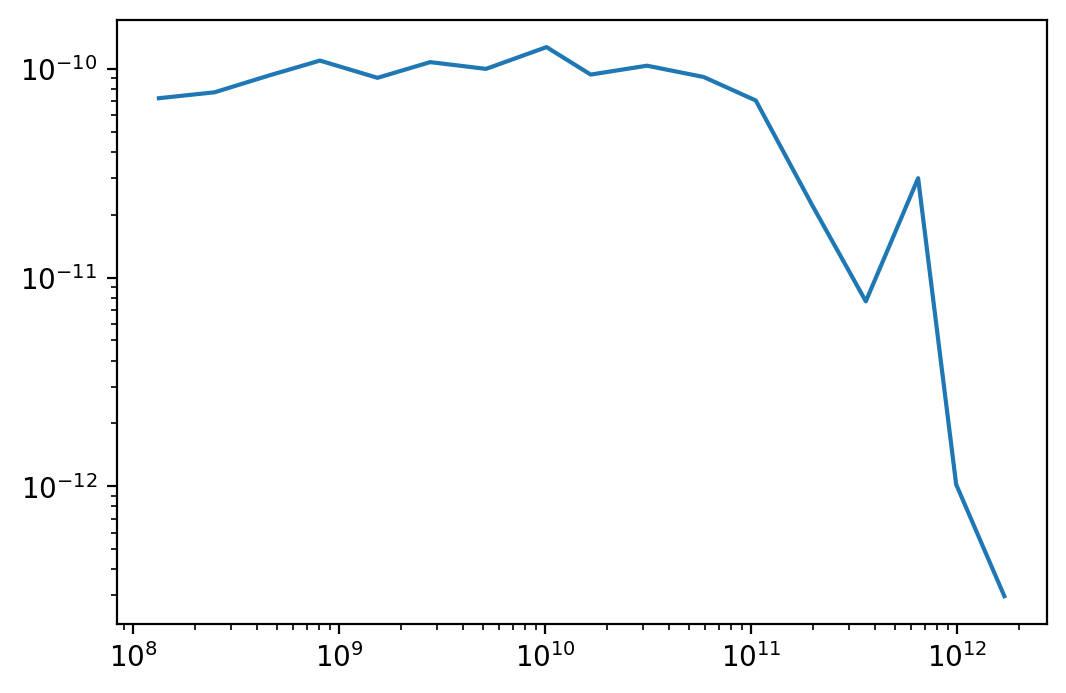

In [15]:
fig, ax = plt.subplots(dpi=200)

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(sSFR_mstar['fiducial']['mstar_mean'], sSFR_mstar['fiducial']['sSFR_mean'], label='fiducial')

In [19]:
# Load sSFR
Nbins_sSFR = 10

zoom_sSFR = {}
for i in range(len(name_list)):
    zoom_sSFR[name_list[i]] = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/sSFR/sSFR_{}_Nbins{:d}.npy".format(name_list[i], Nbins_sSFR), allow_pickle=True)[0]


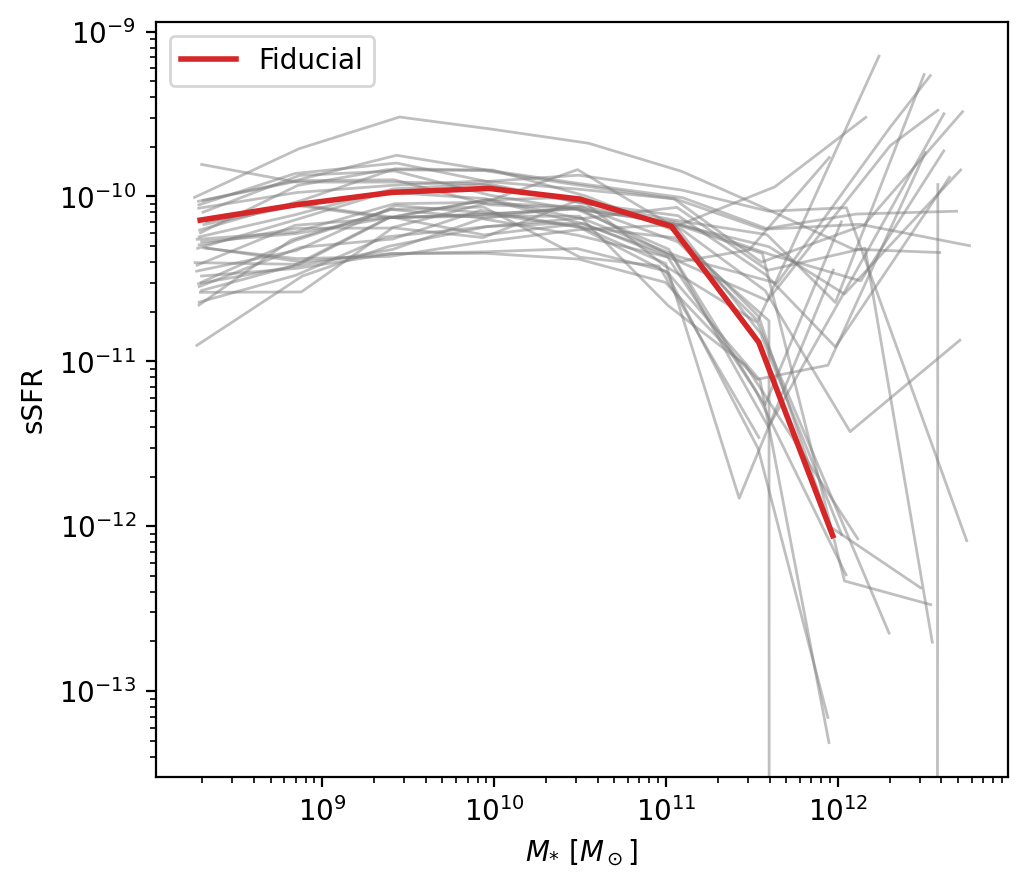

In [20]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel("sSFR")
ax.set_xlabel(r"$M_{*}$ [$M_\odot$]")

for i in range(len(name_list)-1):
    ax.plot(zoom_sSFR[name_list[i]]['mstar_mean'], zoom_sSFR[name_list[i]]['sSFR_mean'], color='gray', alpha=0.5, lw=1)

ax.plot(zoom_sSFR['fiducial']['mstar_mean'], zoom_sSFR['fiducial']['sSFR_mean'], label='Fiducial', color='C3', lw=2)

ax.legend()


In [26]:
zoom_sSFR['LH_4']['sSFR_mean']

array([2.28576830e-11, 3.32464054e-11, 5.67692157e-11, 6.52657761e-11,
       7.39564424e-11, 4.29004412e-11, 2.97569569e-11, 2.63226787e-10,
       5.41165070e-10])

In [13]:
import sys
sys.path.append("/cosmos_storage/home/fgmaion/MTNG-resims/scripts")
from GP_models import SMF_Model, fgas_Model
import torch
import gpytorch

In [26]:
model_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_bhmf.pth")
likelihood_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_bhmf.pth")

model_bhmf.eval()
likelihood_bhmf.eval()

/tmp/ipykernel_386577/2204472259.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

In [27]:
# Define the training set
train_sel = np.arange(31)

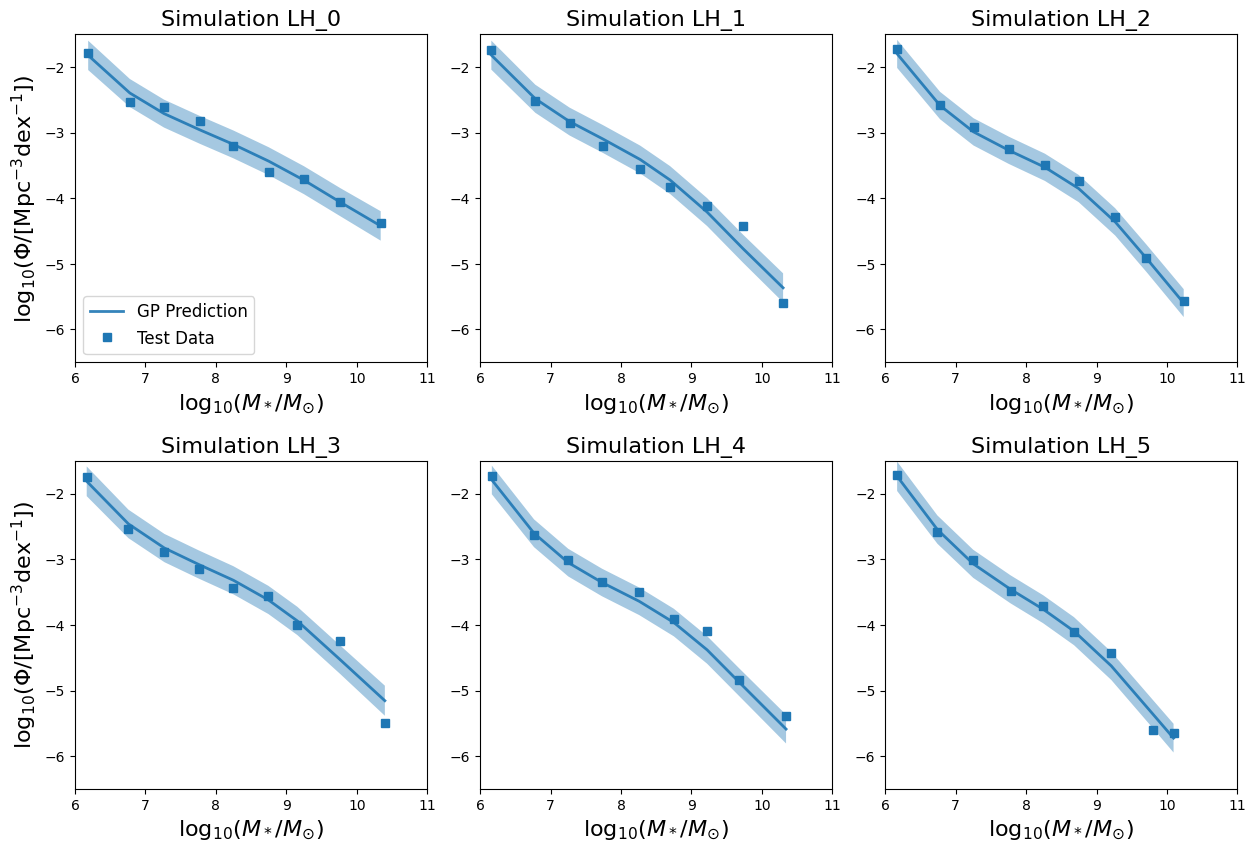

In [36]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(2, 3, figsize=(15, 10), dpi=100)
    plt.subplots_adjust(wspace=0.15, hspace=0.3)

    for i in range(2):
        for j in range(3):
            test_x = torch.asarray(pars(train_sel[3*i+j], np.log10(zoom_bhmf[name_list[train_sel[3*i+j]]]['mbh'])), dtype=torch.float)
            observed_pred = likelihood_bhmf(model_bhmf(torch.asarray(test_x, dtype=torch.float)))
        
            ax[i,j].set_xlim(6,11)
            ax[i,j].set_ylim(-6.5, -1.5)

            ax[i,j].set_title('Simulation {:s}'.format(name_list[train_sel[3*i+j]]), fontsize=16)

            if j==0:
                ax[i,j].set_ylabel('$\log_{10}(\Phi/[\mathrm{Mpc}^{-3}\mathrm{dex}^{-1}])$', fontsize=16)
            
            ax[i,j].set_xlabel('$\log_{10}(M_*/M_{\odot})$', fontsize=16)

            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='C0', alpha=0.4, edgecolor=None)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'C0', lw=2, label="GP Prediction", alpha=0.9)

            # Plot test data as blue squares
            ax[i,j].plot(np.log10(zoom_bhmf[name_list[train_sel[3*i+j]]]['mbh']), np.log10(zoom_bhmf[name_list[train_sel[3*i+j]]]['bhmf']), 's', color="C0", label="Test Data")

ax[0,0].legend(loc='lower left', fontsize=12)

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/results/testing_plots/bhmf_test.pdf", bbox_inches='tight')

In [32]:
import numpy as np
import torch
import gpytorch
import os
import copy

wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']# + ['bf_sim'] 

for i in range(len(name_list)):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    if i==30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"
    if i==31:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_bf.txt"


    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))
        
rho_rec_or = np.log10(rho_rec_or)
ef_kin_or  = np.log10(ef_kin_or)

wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

def pars(i, m2half):

    arr = np.vstack( ( m2half, np.ones(len(m2half)) * wind_en[i],\
                        np.ones(len(m2half)) * wind_vel[i],\
                        np.ones(len(m2half)) * rho_rec[i],\
                        np.ones(len(m2half)) * sf_ts[i],\
                        np.ones(len(m2half)) * ef_kin[i],\
                        np.ones(len(m2half)) * ef_high[i],\
                        np.ones(len(m2half)) * f_re[i])).T

    return arr

# Load Stellar-Mass to Halo-Mass Relation
Nbins_sSFR = 10

zoom_sSFR = {}
for i in range(len(name_list)):
    zoom_sSFR[name_list[i]] = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/sSFR/sSFR_{}_Nbins{:d}.npy".format(name_list[i], Nbins_sSFR), allow_pickle=True)[0]

# Filter NaNs
for i in range(len(name_list)):
    mask = ~np.isnan(zoom_sSFR[name_list[i]]['sSFR_mean']) & ~np.isnan(zoom_sSFR[name_list[i]]['mstar_mean'])
    
    zoom_sSFR[name_list[i]]['sSFR_mean'] = zoom_sSFR[name_list[i]]['sSFR_mean'][mask]
    zoom_sSFR[name_list[i]]['mstar_mean'] = zoom_sSFR[name_list[i]]['mstar_mean'][mask]

# Filter infs
for i in range(len(name_list)):
    mask = ~np.isinf(np.log10(zoom_sSFR[name_list[i]]['sSFR_mean'])) & ~np.isinf(np.log10(zoom_sSFR[name_list[i]]['mstar_mean']))
    
    zoom_sSFR[name_list[i]]['sSFR_mean'] = zoom_sSFR[name_list[i]]['sSFR_mean'][mask]
    zoom_sSFR[name_list[i]]['mstar_mean'] = zoom_sSFR[name_list[i]]['mstar_mean'][mask]

# Define the training set
train_sel = np.arange(31)

pars_global = pars(train_sel[0], np.log10(zoom_sSFR[name_list[train_sel[0]]]['mstar_mean']) )
sSFR_global = np.log10(zoom_sSFR[name_list[train_sel[0]]]['sSFR_mean'])

for i in range(len(train_sel)):
    mstar = np.log10(zoom_sSFR[name_list[train_sel[i]]]['mstar_mean'])

    arr = pars(train_sel[i], mstar)

    pars_global = np.vstack((pars_global, arr))

    sSFR_global = np.hstack((sSFR_global, np.log10(zoom_sSFR[name_list[train_sel[i]]]['sSFR_mean'])))
    
train_x = torch.asarray(pars_global, dtype=torch.float)
train_y = torch.asarray(sSFR_global, dtype=torch.float)

/tmp/ipykernel_89411/1938145976.py:83: RuntimeWarning: divide by zero encountered in log10
  mask = ~np.isinf(np.log10(zoom_sSFR[name_list[i]]['sSFR_mean'])) & ~np.isinf(np.log10(zoom_sSFR[name_list[i]]['mstar_mean']))


In [33]:
train_y

tensor([-10.3125, -10.3769, -10.3639, -10.2747, -10.2023, -10.1701, -10.3049,
        -10.5918,  -9.8388, -10.3125, -10.3769, -10.3639, -10.2747, -10.2023,
        -10.1701, -10.3049, -10.5918,  -9.8388, -10.5210, -10.2672, -10.0785,
        -10.1323, -10.0575, -10.1707, -10.3463, -12.3325, -12.4763, -10.5705,
        -10.4218, -10.1233, -10.2332, -10.1638, -10.3597, -11.3992, -10.5618,
         -9.4982, -10.2452, -10.1135,  -9.9540,  -9.9257, -10.0387, -10.1164,
        -10.4753, -10.9126,  -9.8836, -10.6410, -10.4783, -10.2459, -10.1853,
        -10.1310, -10.3675, -10.5264,  -9.5797,  -9.2667, -10.4011, -10.4119,
        -10.1294, -10.1099, -10.0715, -10.3934, -10.3244,  -9.7638, -10.5289,
        -10.4218, -10.3211, -10.1342, -10.2356, -10.3670, -11.2645, -10.1541,
        -10.2200,  -9.9330,  -9.8372,  -9.8434,  -9.9240, -10.0136, -10.3986,
        -10.1734,  -9.4855, -10.2597, -10.2166, -10.0440, -10.0354,  -9.8372,
        -10.1845,  -9.9421,  -9.5199, -10.4529, -10.3267, -10.05